# Paper Figure 2 Plots

This notebook builds the combined detuning-compensation and phase-compensation paper figure from the analysis objects produced by the two source notebooks.

The default input locations are now cross-folder, so this notebook can be run from either source directory:

- Detuning input: `C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\LineSignal_charaterization\paper_figure2_detuning_inputs.pkl`
- Phase input: `C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Line_signal_compensation\paper_figure2_phase_inputs.pkl`

If you need to regenerate the inputs manually, run the detuning source notebook until `detuning_fit_results_by_comp` exists, then run:

```python
from Paper_figure2_plots import export_detuning_inputs
export_detuning_inputs(detuning_fit_results_by_comp)
```

Run the bussed Ramsey source notebook until `all_transition_zero_detuning_analysis` exists, then run:

```python
from Paper_figure2_plots import export_phase_inputs
export_phase_inputs(all_transition_zero_detuning_analysis)
```


In [80]:
from __future__ import annotations

import argparse
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.lines import Line2D


try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd().resolve()
DETUNING_NOTEBOOK_DIR = Path(
    r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts"
    r"\LineSignal_charaterization"
)
PHASE_NOTEBOOK_DIR = Path(
    r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts"
    r"\Line_signal_compensation"
)
DEFAULT_DETUNING_INPUT = DETUNING_NOTEBOOK_DIR / "paper_figure2_detuning_inputs.pkl"
DEFAULT_PHASE_INPUT = PHASE_NOTEBOOK_DIR / "paper_figure2_phase_inputs.pkl"
DEFAULT_OUTPUT_STEM = SCRIPT_DIR / "paper_figure2_detuning_phase_comp"

DEFAULT_LINE_SIGNAL_FIT_FILE = Path(
    r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts"
    r"\LineSignal_charaterization\line_signal_fit_params_20260514_K10.txt"
)

TEST_TRANSITION_SENSITIVITY_MHZ_PER_G = 3.20153
LINE_FREQ_HZ = 60.0
HARMONIC_K = 10
TEMPLATE_PLOT_MODE = "unit_scale"


def configure_paper_style(use_tex=True):
    rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Computer Modern"],
            "text.usetex": use_tex,
            "font.size": 14,
            "axes.labelsize": 14,
            "axes.titlesize": 16,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "legend.fontsize": 14,
            "axes.linewidth": 0.7,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.major.size": 3,
            "ytick.major.size": 3,
            "xtick.major.width": 0.7,
            "ytick.major.width": 0.7,
            "savefig.dpi": 600,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


def export_detuning_inputs(detuning_fit_results_by_comp, path=DEFAULT_DETUNING_INPUT):
    path = Path(path)
    with path.open("wb") as handle:
        pickle.dump(detuning_fit_results_by_comp, handle)
    return path


def export_phase_inputs(all_transition_zero_detuning_analysis, path=DEFAULT_PHASE_INPUT):
    path = Path(path)
    with path.open("wb") as handle:
        pickle.dump(all_transition_zero_detuning_analysis, handle)
    return path


def _load_pickle(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Export this input from its source notebook first.\n"
            f"  Detuning export target: {DEFAULT_DETUNING_INPUT}\n"
            f"  Phase export target:    {DEFAULT_PHASE_INPUT}"
        )
    with path.open("rb") as handle:
        return pickle.load(handle)


def load_line_signal_fit_params(filename):
    path = Path(filename)
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {str(path)!r}. Set calibration_file to the full path."
        )

    numeric_rows = []
    with path.open("r") as handle:
        for line in handle:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            numeric_rows.append([float(x) for x in line.split()])

    if len(numeric_rows) < 2:
        raise ValueError(f"{str(path)!r} does not contain enough numeric rows.")

    harmonics = []
    for row in numeric_rows[1:]:
        if len(row) < 5:
            raise ValueError("Each harmonic row must contain: f_Hz A A_err phi phi_err")
        f_hz, A_mG, A_err_mG, phi_rad, phi_err_rad = row[:5]
        harmonics.append(
            {
                "f_hz": f_hz,
                "A_mG": A_mG,
                "A_err_mG": A_err_mG,
                "phi_rad": phi_rad,
                "phi_err_rad": phi_err_rad,
            }
        )

    return {
        "filename": str(path),
        "B0_mG": numeric_rows[0][0],
        "B0_err_mG": numeric_rows[0][1] if len(numeric_rows[0]) > 1 else np.nan,
        "harmonics": harmonics,
    }


def evaluate_calibrated_B_template_mG(t_us, calibration, include_offset=False):
    t_s = np.asarray(t_us, dtype=float) * 1e-6
    if include_offset:
        y_mG = np.full_like(t_s, calibration["B0_mG"], dtype=float)
    else:
        y_mG = np.zeros_like(t_s, dtype=float)

    for harmonic in calibration["harmonics"]:
        y_mG += harmonic["A_mG"] * np.cos(
            2.0 * np.pi * harmonic["f_hz"] * t_s + harmonic["phi_rad"]
        )

    return y_mG


def evaluate_calibrated_detuning_template_hz(
    t_us,
    calibration,
    sensitivity_MHz_per_G=TEST_TRANSITION_SENSITIVITY_MHZ_PER_G,
):
    B_template_mG = evaluate_calibrated_B_template_mG(
        t_us,
        calibration,
        include_offset=False,
    )
    return sensitivity_MHz_per_G * 1000.0 * B_template_mG


def total_harmonic_amplitude_error(params, covariance, start_index=1):
    params = np.asarray(params, dtype=float)
    if covariance is None or not np.all(np.isfinite(covariance)):
        return np.nan

    q = params[start_index:]
    A_total = np.sqrt(np.sum(q**2))
    if A_total <= 0:
        return np.nan

    grad = np.zeros_like(params, dtype=float)
    grad[start_index:] = q / A_total
    variance = grad @ covariance @ grad
    return np.sqrt(max(variance, 0.0))


def correlation_error_fisher(rho, n_points):
    if not np.isfinite(rho) or n_points <= 3:
        return np.nan
    sigma_z = 1.0 / np.sqrt(n_points - 3)
    return (1.0 - rho**2) * sigma_z


def ratio_with_error(x_off, sx_off, x_on, sx_on):
    if not np.isfinite(x_off) or not np.isfinite(x_on) or x_on == 0:
        return np.nan, np.nan

    S = abs(x_off) / abs(x_on)
    if not np.isfinite(sx_off) or not np.isfinite(sx_on) or x_off == 0:
        return S, np.nan

    relative_variance = (sx_off / x_off) ** 2 + (sx_on / x_on) ** 2
    return S, S * np.sqrt(relative_variance)


def harmonic_design_matrix(t_us, K=HARMONIC_K, line_freq_hz=LINE_FREQ_HZ):
    t_s = np.asarray(t_us, dtype=float) * 1e-6
    columns = [np.ones_like(t_s)]
    for n in range(1, K + 1):
        omega_t = 2.0 * np.pi * n * line_freq_hz * t_s
        columns.append(np.cos(omega_t))
        columns.append(np.sin(omega_t))
    return np.column_stack(columns)


def fit_harmonic_model(t_us, y_hz, yerr_hz=None, K=HARMONIC_K, line_freq_hz=LINE_FREQ_HZ):
    t_us = np.asarray(t_us, dtype=float)
    y_hz = np.asarray(y_hz, dtype=float)
    valid = np.isfinite(t_us) & np.isfinite(y_hz)

    if yerr_hz is not None:
        yerr_hz = np.asarray(yerr_hz, dtype=float)
        valid &= np.isfinite(yerr_hz) & (yerr_hz > 0)

    t_fit = t_us[valid]
    y_fit = y_hz[valid]
    sigma = yerr_hz[valid] if yerr_hz is not None else None
    n_points = len(y_fit)
    n_params = 2 * K + 1
    dof = n_points - n_params
    if dof <= 0:
        raise ValueError(f"Not enough data points for K={K}: N={n_points}, parameters={n_params}.")

    X = harmonic_design_matrix(t_fit, K=K, line_freq_hz=line_freq_hz)
    use_weights = sigma is not None and np.all(np.isfinite(sigma)) and np.all(sigma > 0)

    if use_weights:
        Xw = X / sigma[:, None]
        yw = y_fit / sigma
        params, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        y_model = X @ params
        residual = y_fit - y_model
        chi2 = np.sum((residual / sigma) ** 2)
        reduced_chi2 = chi2 / dof
        covariance = np.linalg.pinv(Xw.T @ Xw) * reduced_chi2
    else:
        params, *_ = np.linalg.lstsq(X, y_fit, rcond=None)
        y_model = X @ params
        residual = y_fit - y_model
        residual_variance = np.sum(residual**2) / dof
        reduced_chi2 = np.nan
        covariance = np.linalg.pinv(X.T @ X) * residual_variance

    a_coeffs = params[1::2]
    b_coeffs = params[2::2]
    amplitudes = np.sqrt(a_coeffs**2 + b_coeffs**2)
    harmonic_amplitude_norm_hz = np.sqrt(np.sum(amplitudes**2))

    return {
        "K": K,
        "t_us": t_fit,
        "y_hz": y_fit,
        "params": params,
        "covariance": covariance,
        "y_model_hz": y_model,
        "residual_hz": residual,
        "amplitudes_hz": amplitudes,
        "harmonic_amplitude_norm_hz": harmonic_amplitude_norm_hz,
        "harmonic_amplitude_norm_err_hz": total_harmonic_amplitude_error(params, covariance),
        "harmonic_structured_rms_hz": harmonic_amplitude_norm_hz / np.sqrt(2.0),
        "offset_hz": params[0],
        "n_points": n_points,
        "n_params": n_params,
        "dof": dof,
        "reduced_chi2": reduced_chi2,
    }


def template_projection(y_hz, template_hz, yerr_hz=None):
    y_hz = np.asarray(y_hz, dtype=float)
    template_hz = np.asarray(template_hz, dtype=float)
    valid = np.isfinite(y_hz) & np.isfinite(template_hz)
    y = y_hz[valid]
    template = template_hz[valid]
    X = np.column_stack([np.ones_like(template), template])

    use_weights = False
    if yerr_hz is not None:
        sigma = np.asarray(yerr_hz, dtype=float)[valid]
        use_weights = np.all(np.isfinite(sigma)) and np.all(sigma > 0)

    if use_weights:
        Xw = X / sigma[:, None]
        yw = y / sigma
        coeffs, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        residual = y - X @ coeffs
        dof = len(y) - X.shape[1]
        chi2 = np.sum((residual / sigma) ** 2)
        red_chi2 = chi2 / dof if dof > 0 else np.nan
        cov = np.linalg.pinv(Xw.T @ Xw)
        if np.isfinite(red_chi2):
            cov = cov * red_chi2
    else:
        coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
        residual = y - X @ coeffs
        dof = len(y) - X.shape[1]
        red_chi2 = np.nan
        residual_var = np.sum(residual**2) / dof if dof > 0 else np.nan
        cov = np.linalg.pinv(X.T @ X)
        if np.isfinite(residual_var):
            cov = cov * residual_var

    offset = coeffs[0]
    scale = coeffs[1]
    if cov is not None and np.all(np.isfinite(cov)):
        offset_err = np.sqrt(max(cov[0, 0], 0.0))
        scale_err = np.sqrt(max(cov[1, 1], 0.0))
    else:
        offset_err = np.nan
        scale_err = np.nan

    y_fit_full = np.full_like(y_hz, np.nan, dtype=float)
    y_fit_full[valid] = offset + scale * template

    return {
        "scale": scale,
        "scale_err": scale_err,
        "offset_hz": offset,
        "offset_err_hz": offset_err,
        "fit_hz": y_fit_full,
        "dof": dof,
        "reduced_chi2": red_chi2,
    }


def pearson_correlation(y_hz, template_hz):
    y_hz = np.asarray(y_hz, dtype=float)
    template_hz = np.asarray(template_hz, dtype=float)
    valid = np.isfinite(y_hz) & np.isfinite(template_hz)
    y = y_hz[valid]
    template = template_hz[valid]
    y0 = y - np.mean(y)
    t0 = template - np.mean(template)
    denom = np.sqrt(np.sum(y0**2) * np.sum(t0**2))
    if denom == 0:
        return np.nan
    return np.sum(y0 * t0) / denom


def extract_detuning_data_by_comp(detuning_fit_results_by_comp):
    data_by_comp = {}
    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})
        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)
        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )
        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )
        valid = np.isfinite(wait_times) & np.isfinite(detunings)
        if not np.any(valid):
            data_by_comp[comp_flag] = None
            continue

        order = np.argsort(wait_times[valid])
        data_by_comp[comp_flag] = {
            "wait_times_us": wait_times[valid][order],
            "detunings_hz": detunings[valid][order] / (2 * np.pi),
            "detuning_errors_hz": detuning_errors[valid][order] / (2 * np.pi),
        }

    return data_by_comp


def compute_compensation_metrics(
    data_by_comp,
    calibration,
    harmonic_k=HARMONIC_K,
    line_freq_hz=LINE_FREQ_HZ,
    sensitivity_MHz_per_G=TEST_TRANSITION_SENSITIVITY_MHZ_PER_G,
):
    metrics_by_comp = {}
    for comp_flag in (False, True):
        data = data_by_comp.get(comp_flag)
        if data is None:
            metrics_by_comp[comp_flag] = None
            continue

        wait_times = data["wait_times_us"]
        y_hz = data["detunings_hz"]
        yerr_hz = data["detuning_errors_hz"]
        harmonic_fit = fit_harmonic_model(
            wait_times,
            y_hz,
            yerr_hz=yerr_hz,
            K=harmonic_k,
            line_freq_hz=line_freq_hz,
        )
        template_hz = evaluate_calibrated_detuning_template_hz(
            wait_times,
            calibration,
            sensitivity_MHz_per_G=sensitivity_MHz_per_G,
        )
        projection = template_projection(y_hz, template_hz, yerr_hz=yerr_hz)
        rho = pearson_correlation(y_hz, template_hz)
        metrics_by_comp[comp_flag] = {
            "harmonic_fit": harmonic_fit,
            "template_hz": template_hz,
            "projection": projection,
            "correlation_with_template": rho,
            "correlation_err": correlation_error_fisher(rho, n_points=len(y_hz)),
        }

    return metrics_by_comp


def print_compensation_summary(metrics_by_comp, calibration):
    off = metrics_by_comp.get(False)
    on = metrics_by_comp.get(True)
    print("\n" + "=" * 92)
    print("Detuning compensation: structured-signal metrics")
    print("=" * 92)
    print(f"Calibrated AC file: {calibration['filename']}")
    print(f"Transition sensitivity: {TEST_TRANSITION_SENSITIVITY_MHZ_PER_G:.6g} MHz/G")

    for comp_flag, name in [(False, "Compensation OFF"), (True, "Compensation ON")]:
        metrics = metrics_by_comp.get(comp_flag)
        if metrics is None:
            print(f"\n{name}: no valid data")
            continue
        hfit = metrics["harmonic_fit"]
        proj = metrics["projection"]
        print(f"\n{name}")
        print(f"  N points                         = {hfit['n_points']}")
        print(
            f"  Harmonic amplitude A_AC          = "
            f"{hfit['harmonic_amplitude_norm_hz']:.3f} +/- "
            f"{hfit['harmonic_amplitude_norm_err_hz']:.3f} Hz"
        )
        print(
            f"  Matched-filter scale a_AC        = "
            f"{proj['scale']:.5f} +/- {proj['scale_err']:.5f}"
        )
        print(
            f"  Correlation with AC waveform     = "
            f"{metrics['correlation_with_template']:.4f} +/- "
            f"{metrics['correlation_err']:.4f}"
        )

    if off is not None and on is not None:
        A_off = off["harmonic_fit"]["harmonic_amplitude_norm_hz"]
        A_on = on["harmonic_fit"]["harmonic_amplitude_norm_hz"]
        A_off_err = off["harmonic_fit"]["harmonic_amplitude_norm_err_hz"]
        A_on_err = on["harmonic_fit"]["harmonic_amplitude_norm_err_hz"]
        S_A, S_A_err = ratio_with_error(A_off, A_off_err, A_on, A_on_err)
        print("\nSuppression metrics")
        print(f"  Harmonic-amplitude suppression   = {S_A:.2f} +/- {S_A_err:.2f}x")

    print("=" * 92 + "\n")


def plot_detuning_comparison_on_axis(
    ax,
    detuning_fit_results_by_comp,
    calibration_file=DEFAULT_LINE_SIGNAL_FIT_FILE,
    show_calibrated_template=True,
    template_plot_mode=TEMPLATE_PLOT_MODE,
    print_summary=True,
):
    calibration = load_line_signal_fit_params(calibration_file)
    data_by_comp = extract_detuning_data_by_comp(detuning_fit_results_by_comp)
    metrics_by_comp = compute_compensation_metrics(data_by_comp, calibration)

    colors = {False: "C0", True: "C1"}
    labels = {False: "Compensation off", True: "Compensation on"}
    markers = {False: "o", True: "D"}
    plotted_any = False

    for comp_flag in (False, True):
        data = data_by_comp.get(comp_flag)
        if data is None:
            continue

        yerr = np.where(np.isfinite(data["detuning_errors_hz"]), data["detuning_errors_hz"], 0.0)
        ax.errorbar(
            data["wait_times_us"] / 1000.0,
            data["detunings_hz"]/1000,
            yerr=yerr/1000,
            fmt=markers[comp_flag],
            markersize=5.2,
            capsize=2.2,
            elinewidth=0.8,
            markeredgewidth=0.6,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=labels[comp_flag],
            zorder=3,
        )
        plotted_any = True

    if not plotted_any:
        raise ValueError("No finite detuning points found.")

    if print_summary:
        print_compensation_summary(metrics_by_comp, calibration)

    if show_calibrated_template:
        valid_data = [data for data in data_by_comp.values() if data is not None]
        t_min = min(np.min(data["wait_times_us"]) for data in valid_data)
        t_max = max(np.max(data["wait_times_us"]) for data in valid_data)
        t_template_us = np.linspace(t_min, t_max, 1500)
        template_hz = evaluate_calibrated_detuning_template_hz(t_template_us, calibration)
        off_projection = metrics_by_comp[False]["projection"]

        if template_plot_mode == "unit_scale":
            y_template_plot = off_projection["offset_hz"] + template_hz
            template_label = "Calibrated \n AC line-signal"
        elif template_plot_mode == "projection_off":
            y_template_plot = off_projection["offset_hz"] + off_projection["scale"] * template_hz
            template_label = "Template projection"
        else:
            raise ValueError(f"Unknown template_plot_mode: {template_plot_mode}")

        ax.plot(
            t_template_us / 1000.0,
            y_template_plot/1000,
            color="C2",
            linestyle="--",
            linewidth=1.25,
            alpha=0.95,
            label=template_label,
            zorder=2,
        )

    ax.axhline(0.0, color="0.2", linewidth=0.8, alpha=0.8, zorder=1)
    ax.set_xlabel(r"Line-trigger delay ($T_{\mathrm{LT}}$) [ms]")
    ax.set_ylabel("Detuning (kHz)", labelpad=0)
    ax.set_title("Detuning compensation", pad=4)
    ax.grid(True, which="major", linewidth=0.45, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # Figure-level legend is added below the subplot row.

    return metrics_by_comp, calibration


def _to_pm1(y_mod2_over_pi):
    y = np.asarray(y_mod2_over_pi, dtype=float)
    return ((y + 1.0) % 2.0) - 1.0


def _unwrap_over_pi(y_over_pi):
    y = np.asarray(y_over_pi, dtype=float)
    return np.unwrap(y * np.pi) / np.pi


def trend_unwrap(phase_wrapped, x=None, history=3, max_branch=3):
    phase_wrapped = np.asarray(phase_wrapped, dtype=float)
    if x is None:
        x = np.arange(len(phase_wrapped), dtype=float)
    else:
        x = np.asarray(x, dtype=float)

    if len(phase_wrapped) != len(x):
        raise ValueError("phase_wrapped and x must have the same length.")

    phase_unwrapped = np.zeros_like(phase_wrapped)
    phase_unwrapped[0] = phase_wrapped[0]

    for i in range(1, min(history, len(phase_wrapped))):
        candidates = phase_wrapped[i] + 2 * np.pi * np.arange(-max_branch, max_branch + 1)
        phase_unwrapped[i] = candidates[np.argmin(np.abs(candidates - phase_unwrapped[i - 1]))]

    for i in range(history, len(phase_wrapped)):
        idx = np.arange(i - history, i)
        slope, intercept = np.polyfit(x[idx], phase_unwrapped[idx], deg=1)
        predicted = slope * x[i] + intercept
        candidates = phase_wrapped[i] + 2 * np.pi * np.arange(-max_branch, max_branch + 1)
        phase_unwrapped[i] = candidates[np.argmin(np.abs(candidates - predicted))]

    return phase_unwrapped


def unwrap_using_reference_offsets(y_mod2_over_pi, y_ref_unwrapped_over_pi):
    y_mod2 = np.asarray(y_mod2_over_pi, dtype=float)
    yref = np.asarray(y_ref_unwrapped_over_pi, dtype=float)
    y0 = _to_pm1(y_mod2)
    reference_offsets = np.round((yref - _to_pm1(yref)) / 2.0) * 2.0
    return y0 + reference_offsets


def _prepare_bussed_ramsey_theory_curves(payload, do_unwrap=True):
    xt = np.asarray(payload["theory_wait_us"], dtype=float)
    yref = np.asarray(payload["theory_ref_phase_mod_over_pi"], dtype=float)
    yfit = np.asarray(payload["theory_fit_phase_mod_over_pi"], dtype=float)

    order = np.argsort(xt)
    xt = xt[order]
    yref = yref[order]
    yfit = yfit[order]

    yref_pm1 = _to_pm1(yref)
    yfit_pm1 = _to_pm1(yfit)

    if do_unwrap:
        yref_plot = _unwrap_over_pi(yref_pm1)
        yfit_plot = _unwrap_over_pi(yfit_pm1)
    else:
        yref_plot = yref_pm1
        yfit_plot = yfit_pm1

    return xt, yref_plot, yfit_plot


def _prepare_bussed_ramsey_experiment_curve(payload, do_unwrap=True, guided=True):
    x = np.asarray(payload["exp_wait_us"], dtype=float)
    y = np.asarray(payload["exp_phase_mod_over_pi"], dtype=float)
    yerr = np.asarray(payload["exp_phase_mod_err_over_pi"], dtype=float)

    order = np.argsort(x)
    x = x[order]
    y = y[order]
    yerr = yerr[order]

    y_wrapped_pm1 = _to_pm1(y)
    if do_unwrap:
        if guided:
            xt_ref, yref_plot, _ = _prepare_bussed_ramsey_theory_curves(payload, do_unwrap=True)
            yref_at_x = np.interp(x, xt_ref, yref_plot)
            y_plot = unwrap_using_reference_offsets(y, yref_at_x)
        else:
            y_plot = trend_unwrap(y_wrapped_pm1 * np.pi, x=x, history=5, max_branch=5) / np.pi
    else:
        y_plot = y_wrapped_pm1

    return x, y_plot, yerr


def _is_side_transition(transitions, side_match="[0, 3, 2]"):
    return side_match in str(transitions)


def plot_phase_compensation_on_axes(
    ax_main,
    ax_side,
    transition_analysis,
    guided=False,
    do_unwrap=True,
    side_match="[0, 3, 2]",
):
    if not transition_analysis:
        raise ValueError("transition_analysis is empty.")

    comp_styles = {
        False: {
            "marker": "o",
            "color": "C0",
            "markerfacecolor": "C0",
            "label": "Compensation off",
        },
        True: {
            "marker": "D",
            "color": "C1",
            "markerfacecolor": "C1",
            "label": "Compensation on",
        },
    }

    main_items = [
        item
        for item in transition_analysis
        if not _is_side_transition(item["transitions"], side_match=side_match)
    ]
    side_items = [
        item
        for item in transition_analysis
        if _is_side_transition(item["transitions"], side_match=side_match)
    ]

    def plot_transition_on_axis(axis, item, zorder_base=2):
        payload_dict = item["payloads"]
        for LT in [False, True]:
            if LT not in payload_dict:
                continue

            payload = payload_dict[LT]
            style = comp_styles[LT]
            x_exp, y_exp_plot, yerr = _prepare_bussed_ramsey_experiment_curve(
                payload,
                do_unwrap=do_unwrap,
                guided=guided,
            )
            axis.errorbar(
                x_exp / 1000.0,
                y_exp_plot,
                yerr=yerr,
                fmt=style["marker"],
                markersize=5.2,
                capsize=2.0,
                color=style["color"],
                ecolor=style["color"],
                elinewidth=0.75,
                markerfacecolor=style["markerfacecolor"],
                markeredgecolor=style["color"],
                alpha=0.9,
                zorder=zorder_base + 1,
                label=style["label"],
            )

            if LT is False:
                xt_theory, yref_plot, _ = _prepare_bussed_ramsey_theory_curves(
                    payload,
                    do_unwrap=do_unwrap,
                )
                axis.plot(
                    xt_theory / 1000.0,
                    yref_plot,
                    linestyle="--",
                    color="C3",
                    linewidth=1.15,
                    alpha=0.95,
                    zorder=zorder_base,
                    label="Calibrated phase" + "\n" + r"$\Phi_{\textrm{AC}}$",
                )

    for item in main_items:
        plot_transition_on_axis(ax_main, item, zorder_base=2)
    for item in side_items:
        plot_transition_on_axis(ax_side, item, zorder_base=2)

    for axis in [ax_main, ax_side]:
        axis.axhline(0.0, color="0.25", linewidth=0.75, zorder=1)
        axis.set_xlabel(r"Wait time ($\tau$) [ms]")
        axis.set_ylabel(r"Phase ($\pi$ rad)", labelpad=0)
        axis.grid(True, which="major", linewidth=0.45, alpha=0.25)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.tick_params(axis="both", direction="in")

    ax_main.set_title("Phase compensation " + r"($\kappa  \approx -0.1$ MHz/G)", pad=4)
    ax_side.set_title("Phase compensation " + r"($\kappa  \approx 3.2$ MHz/G)", pad=4)


    return {"main_items": main_items, "side_items": side_items}


def make_paper_figure2_legend_handles():
    return [
        Line2D(
            [0], [0],
            color="C0",
            marker="o",
            linestyle="None",
            markersize=6.2,
            markerfacecolor="C0",
            markeredgecolor="C0",
            label="Compensation off",
        ),
        Line2D(
            [0], [0],
            color="C1",
            marker="D",
            linestyle="None",
            markersize=6.2,
            markerfacecolor="C1",
            markeredgecolor="C1",
            label="Compensation on",
        ),
        Line2D(
            [0], [0],
            color="C2",
            linestyle="--",
            linewidth=2,
            label="Calibrated AC line-signal",
        ),
        Line2D(
            [0], [0],
            color="C3",
            linestyle="--",
            linewidth=2,
            label=r"Calibrated phase $\Phi_{\mathrm{AC}}$",
        ),
    ]


def add_panel_labels(axes, labels=("a", "b", "c"), use_tex=True):
    for ax, label in zip(axes, labels):
        text = rf"\textbf{{{label}}}" if use_tex else label
        ax.text(
            -0.17,
            1.08,
            text,
            transform=ax.transAxes,
            fontsize=16,
            va="top",
            ha="left",
        )


def save_figure(fig, output_stem=DEFAULT_OUTPUT_STEM, formats=("pdf", "png", "svg")):
    output_stem = Path(output_stem)
    saved_paths = []
    for fmt in formats:
        fmt = fmt.lower().lstrip(".")
        path = output_stem.with_suffix(f".{fmt}")
        if fmt == "png":
            fig.savefig(path, dpi=600, bbox_inches="tight", pad_inches=0)
        else:
            fig.savefig(path, bbox_inches="tight", pad_inches=0)
        saved_paths.append(path)
    return saved_paths


def make_paper_figure2(
    detuning_fit_results_by_comp,
    all_transition_zero_detuning_analysis,
    calibration_file=DEFAULT_LINE_SIGNAL_FIT_FILE,
    output_stem=DEFAULT_OUTPUT_STEM,
    use_tex=True,
    figsize=(14.5, 4.4),
    side_match="[0, 3, 2]",
    save=True,
    formats=("pdf", "png", "svg"),
    show=True,
    print_summary=True,
):
    configure_paper_style(use_tex=use_tex)

    fig = plt.figure(figsize=figsize)
    grid = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.0, 1.0], wspace=0.12)
    ax_detuning = fig.add_subplot(grid[0, 0])
    ax_phase_main = fig.add_subplot(grid[0, 1])
    ax_phase_side = fig.add_subplot(grid[0, 2])

    detuning_metrics, calibration = plot_detuning_comparison_on_axis(
        ax_detuning,
        detuning_fit_results_by_comp,
        calibration_file=calibration_file,
        print_summary=print_summary,
    )
    phase_results = plot_phase_compensation_on_axes(
        ax_phase_main,
        ax_phase_side,
        all_transition_zero_detuning_analysis,
        guided=False,
        do_unwrap=True,
        side_match=side_match,
    )

    # add_panel_labels(
    #     [ax_detuning, ax_phase_main, ax_phase_side],
    #     labels=("a", "b", "c"),
    #     use_tex=use_tex,
    # )

    fig.legend(
        handles=make_paper_figure2_legend_handles(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=4,
        frameon=False,
        handlelength=2.0,
        columnspacing=1.6,
    )

    fig.subplots_adjust(left=0.065, right=0.995, bottom=0.27, top=0.88, wspace=0.22)

    saved_paths = []
    if save:
        saved_paths = save_figure(fig, output_stem=output_stem, formats=formats)

    if show:
        plt.show()

    return {
        "fig": fig,
        "axes": {
            "detuning": ax_detuning,
            "phase_main": ax_phase_main,
            "phase_sensitive": ax_phase_side,
        },
        "detuning_metrics": detuning_metrics,
        "line_signal_calibration": calibration,
        "phase_results": phase_results,
        "saved_paths": saved_paths,
    }


def make_paper_figure2_from_files(
    detuning_input=DEFAULT_DETUNING_INPUT,
    phase_input=DEFAULT_PHASE_INPUT,
    **kwargs,
):
    detuning_fit_results_by_comp = _load_pickle(detuning_input)
    all_transition_zero_detuning_analysis = _load_pickle(phase_input)
    return make_paper_figure2(
        detuning_fit_results_by_comp,
        all_transition_zero_detuning_analysis,
        **kwargs,
    )



Detuning compensation: structured-signal metrics
Calibrated AC file: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\LineSignal_charaterization\line_signal_fit_params_20260514_K10.txt
Transition sensitivity: 3.20153 MHz/G

Compensation OFF
  N points                         = 35
  Harmonic amplitude A_AC          = 1093.859 +/- 17.217 Hz
  Matched-filter scale a_AC        = 0.98216 +/- 0.01784
  Correlation with AC waveform     = 0.9946 +/- 0.0019

Compensation ON
  N points                         = 35
  Harmonic amplitude A_AC          = 131.523 +/- 13.212 Hz
  Matched-filter scale a_AC        = -0.04772 +/- 0.02084
  Correlation with AC waveform     = -0.3575 +/- 0.1542

Suppression metrics
  Harmonic-amplitude suppression   = 8.32 +/- 0.85x



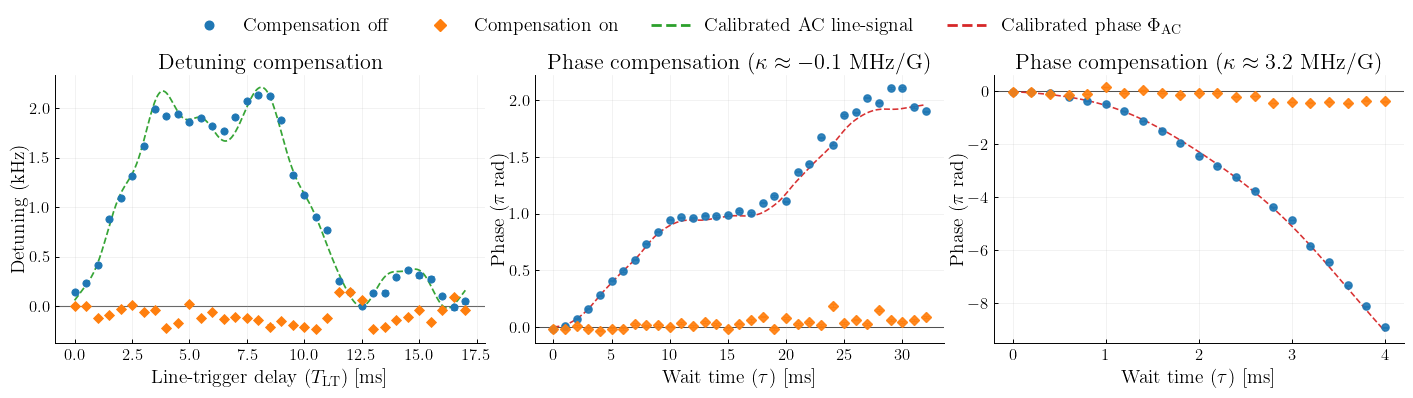

In [81]:
# Run this after exporting both input pickle files.
result = make_paper_figure2_from_files()
